In [29]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from atow_estimation.paths import PROCESSED_DATA_DIR
from atow_estimation.config import (
    M1_M_FEATURES,
    M2_M_FEATURES,
    H_FEATURES,
    M_FEATURES,
    CATEGORICAL_VARIABLES_M1_M,
    CATEGORICAL_VARIABLES_M2_M,
    CATEGORICAL_VARIABLES_H,
    CATEGORICAL_VARIABLES_M,    
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from scipy import stats

whole data

In [5]:
data_m1_M = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'processed_data_m1_M.csv'))
data_m2_M = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'processed_data_m2_M.csv'))
data_H = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'processed_data_H.csv'))
data_M = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'processed_data_M.csv'))

In [51]:
full_data = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'processed_dataset.csv'))

feature selection

In [8]:
data_m1_M = data_m1_M[M1_M_FEATURES]
data_m2_M = data_m2_M[M2_M_FEATURES]
data_H = data_H[H_FEATURES]
data_M = data_M[M_FEATURES]

## Correlation ratio (https://en.wikipedia.org/wiki/Correlation_ratio)

In [10]:
def correlation_ratio(categories, measurements):
    categories = np.asarray(categories)
    measurements = np.asarray(measurements)
    # Calculate means for each category
    cat_means = {category: measurements[categories == category].mean() 
                 for category in np.unique(categories)}
    # Overall mean of measurements
    overall_mean = measurements.mean()
    # Calculate the "between group" sum of squares
    sst = sum(((cat_means[category] - overall_mean) ** 2) * sum(categories == category) 
              for category in cat_means.keys())
    # Calculate the total sum of squares
    sstot = sum((measurement - overall_mean) ** 2 for measurement in measurements)
    # Return the correlation ratio
    return np.sqrt(sst / sstot)

## m1_M

In [12]:
numeric_cols = data_m1_M.select_dtypes(include=['int64', 'float64']).columns.difference(CATEGORICAL_VARIABLES_M1_M)

In [13]:
correlation_matrix = pd.DataFrame(index=CATEGORICAL_VARIABLES_M1_M, columns=numeric_cols)
# Compute the correlation ratio for each pair
for cat in CATEGORICAL_VARIABLES_M1_M:
    for num in numeric_cols:
        try:
            correlation_matrix.loc[cat, num] = correlation_ratio(data_m1_M[cat], data_m1_M[num])
        except Exception:
            correlation_matrix.loc[cat, num] = np.nan
# Convert to float
correlation_matrix = correlation_matrix.T.astype(float)

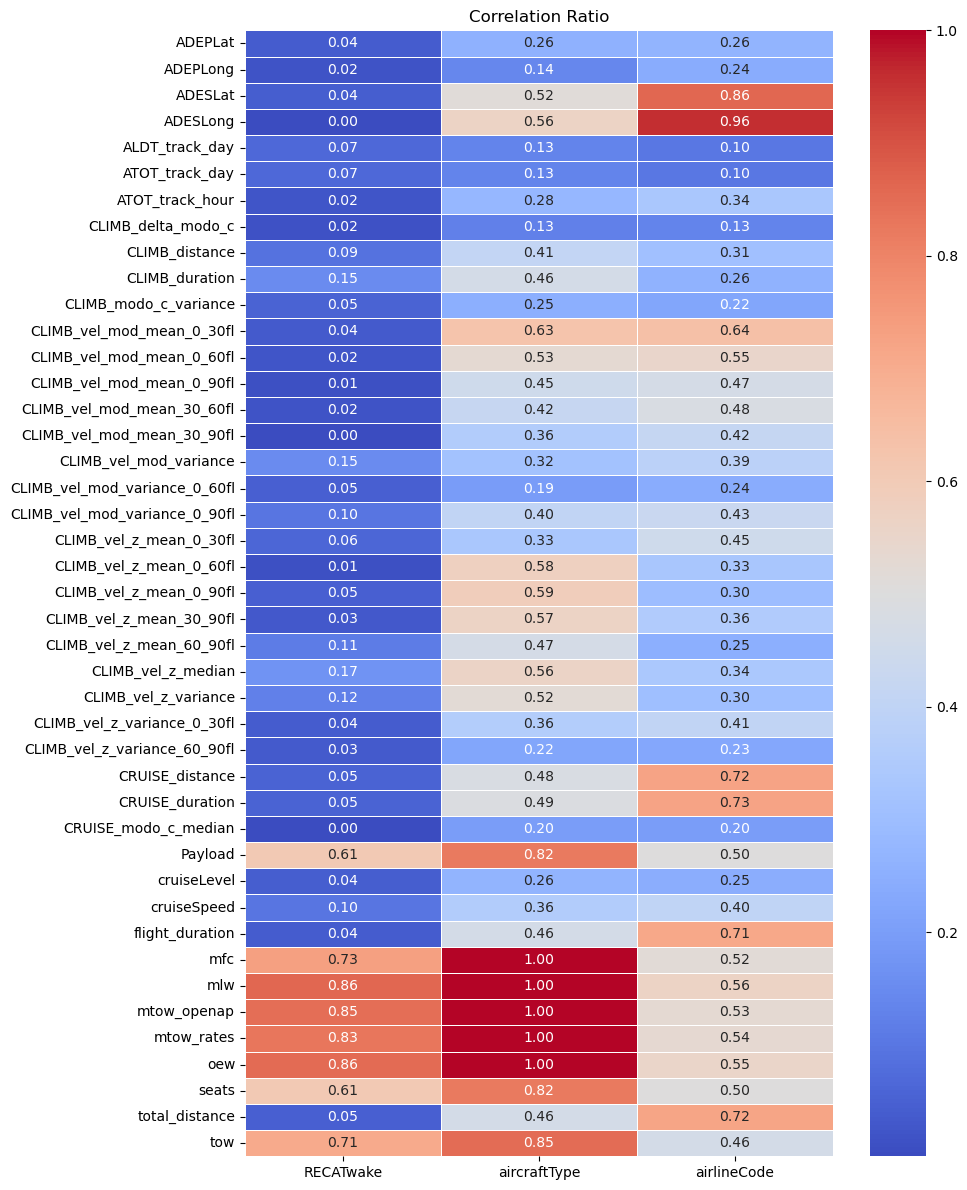

In [16]:
plt.figure(figsize=(10, 12))
sns.heatmap(correlation_matrix, fmt=".2f", cmap='coolwarm', annot=True, linewidths=0.5)
plt.title('Correlation Ratio')
plt.tight_layout()
plt.show()

## m2_M

In [17]:
numeric_cols = data_m2_M.select_dtypes(include=['int64', 'float64']).columns.difference(CATEGORICAL_VARIABLES_M2_M)

In [18]:
correlation_matrix = pd.DataFrame(index=CATEGORICAL_VARIABLES_M2_M, columns=numeric_cols)
# Compute the correlation ratio for each pair
for cat in CATEGORICAL_VARIABLES_M2_M:
    for num in numeric_cols:
        try:
            correlation_matrix.loc[cat, num] = correlation_ratio(data_m2_M[cat], data_m2_M[num])
        except Exception:
            correlation_matrix.loc[cat, num] = np.nan
# Convert to float
correlation_matrix = correlation_matrix.T.astype(float)

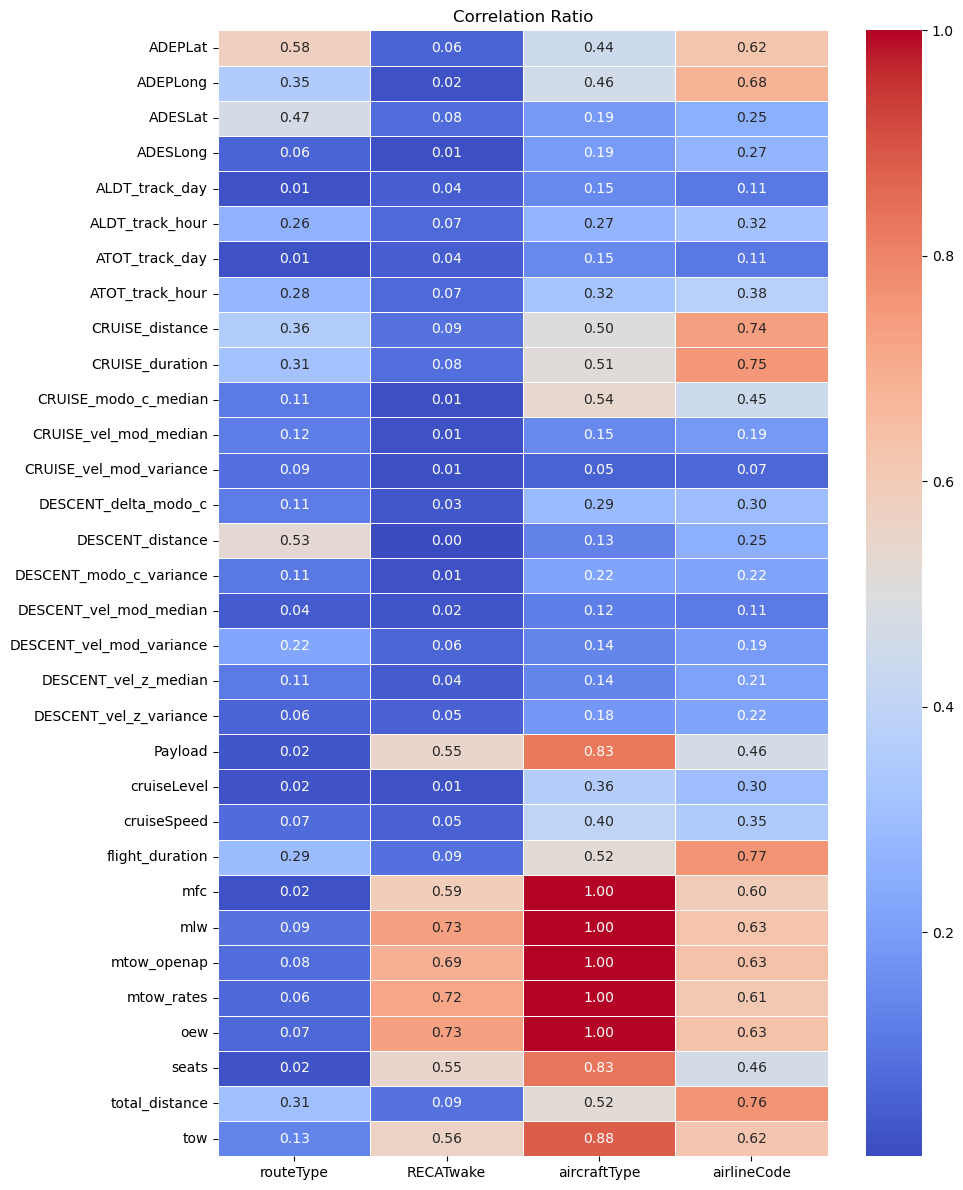

In [19]:
plt.figure(figsize=(10, 12))
sns.heatmap(correlation_matrix, fmt=".2f", cmap='coolwarm', annot=True, linewidths=0.5)
plt.title('Correlation Ratio')
plt.tight_layout()
plt.show()

## H

In [20]:
numeric_cols = data_H.select_dtypes(include=['int64', 'float64']).columns.difference(CATEGORICAL_VARIABLES_H)

In [21]:
correlation_matrix = pd.DataFrame(index=CATEGORICAL_VARIABLES_H, columns=numeric_cols)
# Compute the correlation ratio for each pair
for cat in CATEGORICAL_VARIABLES_H:
    for num in numeric_cols:
        try:
            correlation_matrix.loc[cat, num] = correlation_ratio(data_H[cat], data_H[num])
        except Exception:
            correlation_matrix.loc[cat, num] = np.nan
# Convert to float
correlation_matrix = correlation_matrix.T.astype(float)

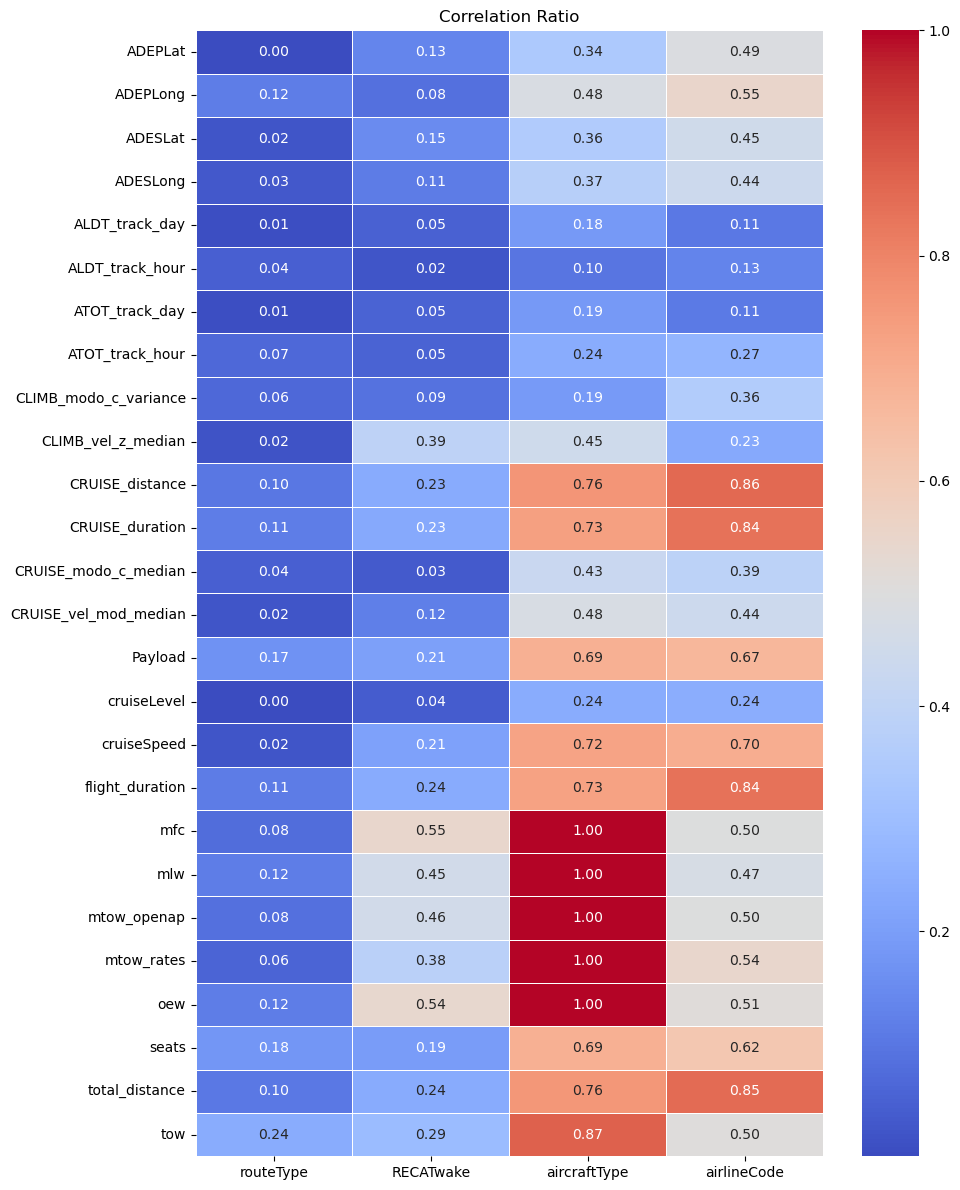

In [22]:
plt.figure(figsize=(10, 12))
sns.heatmap(correlation_matrix, fmt=".2f", cmap='coolwarm', annot=True, linewidths=0.5)
plt.title('Correlation Ratio')
plt.tight_layout()
plt.show()

## M

In [23]:
numeric_cols = data_M.select_dtypes(include=['int64', 'float64']).columns.difference(CATEGORICAL_VARIABLES_M)

In [24]:
correlation_matrix = pd.DataFrame(index=CATEGORICAL_VARIABLES_M, columns=numeric_cols)
# Compute the correlation ratio for each pair
for cat in CATEGORICAL_VARIABLES_M:
    for num in numeric_cols:
        try:
            correlation_matrix.loc[cat, num] = correlation_ratio(data_M[cat], data_M[num])
        except Exception:
            correlation_matrix.loc[cat, num] = np.nan
# Convert to float
correlation_matrix = correlation_matrix.T.astype(float)

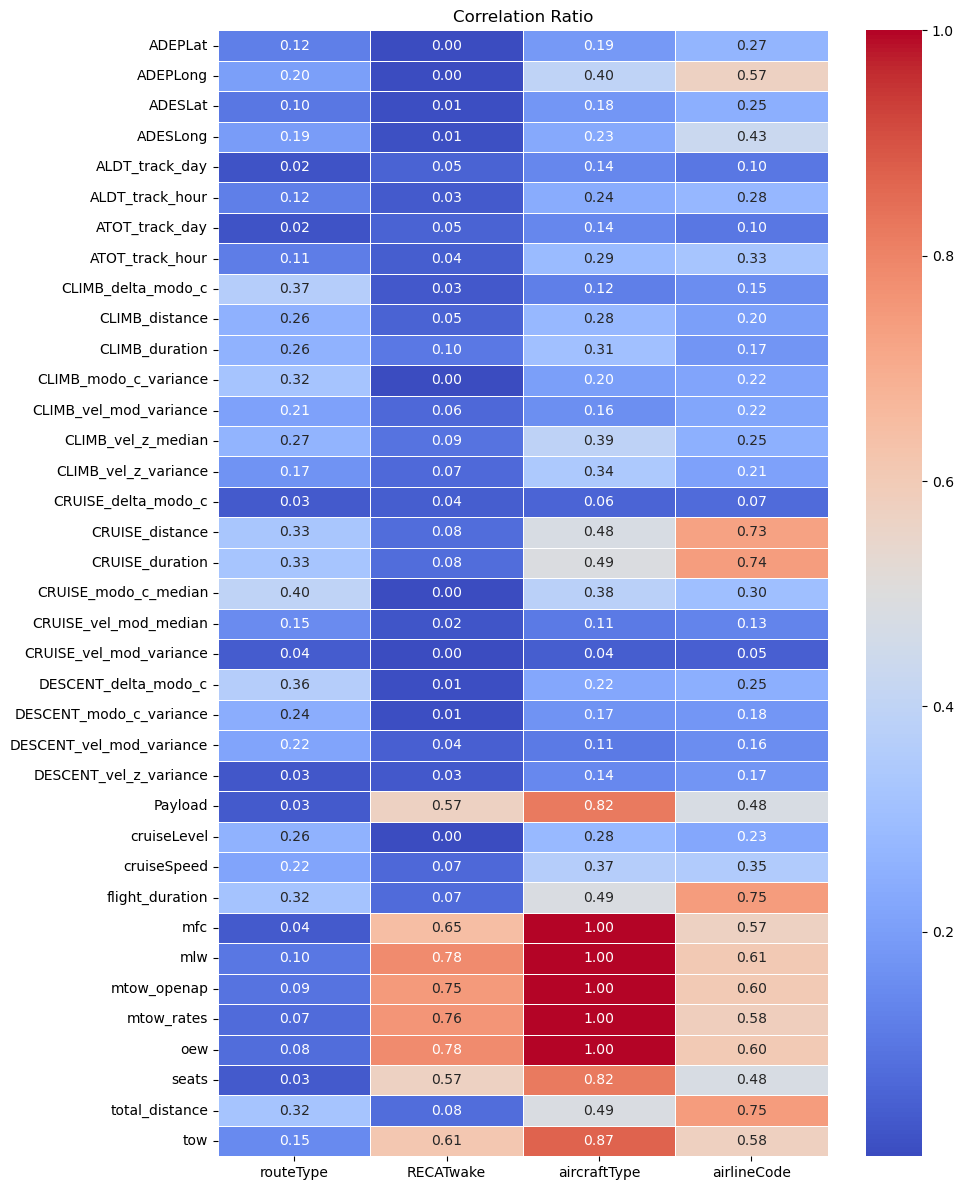

In [25]:
plt.figure(figsize=(10, 12))
sns.heatmap(correlation_matrix, fmt=".2f", cmap='coolwarm', annot=True, linewidths=0.5)
plt.title('Correlation Ratio')
plt.tight_layout()
plt.show()

## Point-biserial correlation coefficient (https://en.wikipedia.org/wiki/Point-biserial_correlation_coefficient)

## m1_M

In [27]:
numeric_cols = data_m1_M.select_dtypes(include=['int64', 'float64']).columns.difference(CATEGORICAL_VARIABLES_M1_M)

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', list(numeric_cols)),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='error'), CATEGORICAL_VARIABLES_M1_M),
    ]
)

data_processed = preprocessor.fit_transform(data_m1_M)

encoder = preprocessor.named_transformers_['cat']
data_processed_df = pd.DataFrame(
    data_processed, 
    columns=list(numeric_cols) + list(encoder.get_feature_names_out(CATEGORICAL_VARIABLES_M1_M)),
    index=data_m1_M.index
)

encoded_categorical = [col for col in data_processed_df.columns if col not in numeric_cols]
pointbiserial_matrix = pd.DataFrame(index=encoded_categorical, columns=numeric_cols)

for cat in encoded_categorical:
    for num in numeric_cols:
        try:
            pointbiserial_matrix.loc[cat, num] = stats.pointbiserialr(data_processed_df[cat], data_processed_df[num])[0]
        except Exception:
            pointbiserial_matrix.loc[cat, num] = np.nan

# Convert to float
pointbiserial_matrix = pointbiserial_matrix.T.astype(float)

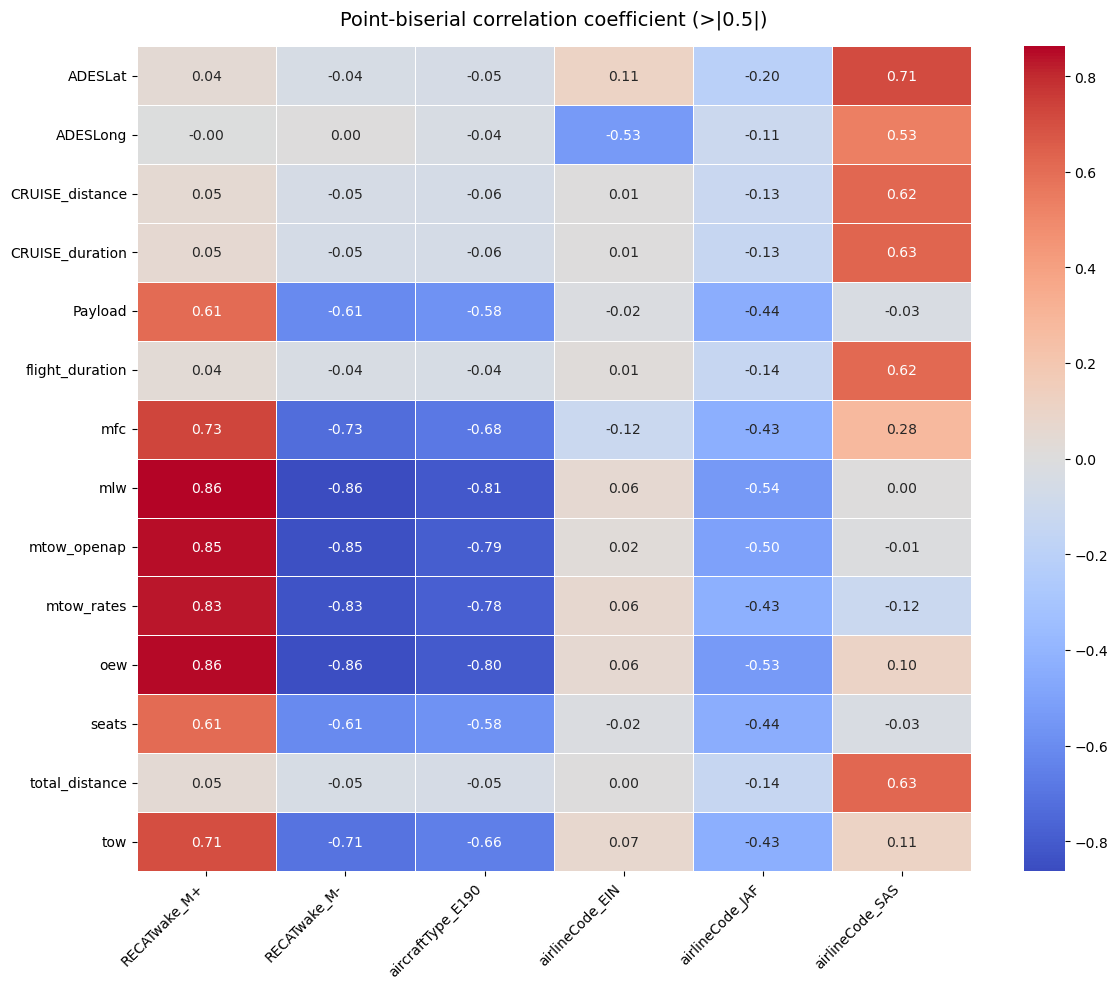

In [32]:
# --- 1) Threshold and filtering ---
threshold = 0.5

# Boolean masks for "any strong corr." per row and per column
rows_to_keep = (abs(pointbiserial_matrix) >= threshold).any(axis=1)
cols_to_keep = (abs(pointbiserial_matrix) >= threshold).any(axis=0)

# Subset the matrix
pointbiserial_matrix_filtered = pd.DataFrame(index=rows_to_keep[rows_to_keep == True].index, columns=cols_to_keep[cols_to_keep == True].index)

for cat in cols_to_keep[cols_to_keep == True].index:
    for num in rows_to_keep[rows_to_keep == True].index:
        try:
            pointbiserial_matrix_filtered.loc[num, cat] = stats.pointbiserialr(data_processed_df[cat], data_processed_df[num])[0]
        except Exception:
            pointbiserial_matrix_filtered.loc[num, cat] = np.nan
            
pointbiserial_matrix_filtered = pointbiserial_matrix_filtered.astype(float)            

plt.figure(figsize=(12, 10))
plt.title(f"Point-biserial correlation coefficient (>|{threshold}|)", pad=16, fontsize=14)
sns.heatmap(pointbiserial_matrix_filtered, fmt=".2f", cmap='coolwarm', annot=True, linewidths=0.5)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## m2_M

In [33]:
numeric_cols = data_m2_M.select_dtypes(include=['int64', 'float64']).columns.difference(CATEGORICAL_VARIABLES_M2_M)

In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', list(numeric_cols)),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='error'), CATEGORICAL_VARIABLES_M2_M),
    ]
)

data_processed = preprocessor.fit_transform(data_m2_M)

encoder = preprocessor.named_transformers_['cat']
data_processed_df = pd.DataFrame(
    data_processed, 
    columns=list(numeric_cols) + list(encoder.get_feature_names_out(CATEGORICAL_VARIABLES_M2_M)),
    index=data_m2_M.index
)

encoded_categorical = [col for col in data_processed_df.columns if col not in numeric_cols]
pointbiserial_matrix = pd.DataFrame(index=encoded_categorical, columns=numeric_cols)

for cat in encoded_categorical:
    for num in numeric_cols:
        try:
            pointbiserial_matrix.loc[cat, num] = stats.pointbiserialr(data_processed_df[cat], data_processed_df[num])[0]
        except Exception:
            pointbiserial_matrix.loc[cat, num] = np.nan

# Convert to float
pointbiserial_matrix = pointbiserial_matrix.T.astype(float)

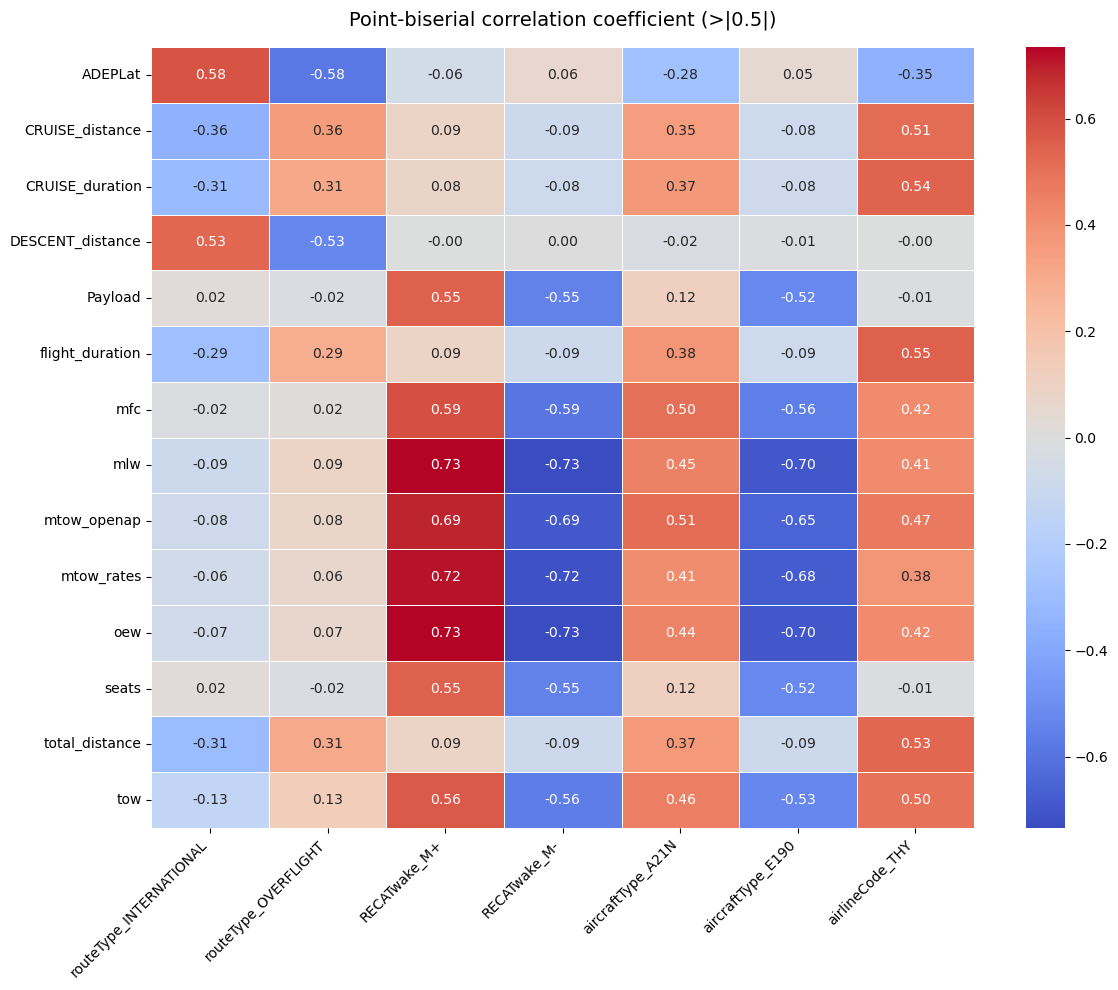

In [35]:
# --- 1) Threshold and filtering ---
threshold = 0.5

# Boolean masks for "any strong corr." per row and per column
rows_to_keep = (abs(pointbiserial_matrix) >= threshold).any(axis=1)
cols_to_keep = (abs(pointbiserial_matrix) >= threshold).any(axis=0)

# Subset the matrix
pointbiserial_matrix_filtered = pd.DataFrame(index=rows_to_keep[rows_to_keep == True].index, columns=cols_to_keep[cols_to_keep == True].index)

for cat in cols_to_keep[cols_to_keep == True].index:
    for num in rows_to_keep[rows_to_keep == True].index:
        try:
            pointbiserial_matrix_filtered.loc[num, cat] = stats.pointbiserialr(data_processed_df[cat], data_processed_df[num])[0]
        except Exception:
            pointbiserial_matrix_filtered.loc[num, cat] = np.nan
            
pointbiserial_matrix_filtered = pointbiserial_matrix_filtered.astype(float)            

plt.figure(figsize=(12, 10))
plt.title(f"Point-biserial correlation coefficient (>|{threshold}|)", pad=16, fontsize=14)
sns.heatmap(pointbiserial_matrix_filtered, fmt=".2f", cmap='coolwarm', annot=True, linewidths=0.5)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## H

In [36]:
numeric_cols = data_H.select_dtypes(include=['int64', 'float64']).columns.difference(CATEGORICAL_VARIABLES_H)

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', list(numeric_cols)),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='error'), CATEGORICAL_VARIABLES_H),
    ]
)

data_processed = preprocessor.fit_transform(data_H)

encoder = preprocessor.named_transformers_['cat']
data_processed_df = pd.DataFrame(
    data_processed, 
    columns=list(numeric_cols) + list(encoder.get_feature_names_out(CATEGORICAL_VARIABLES_H)),
    index=data_H.index
)

encoded_categorical = [col for col in data_processed_df.columns if col not in numeric_cols]
pointbiserial_matrix = pd.DataFrame(index=encoded_categorical, columns=numeric_cols)

for cat in encoded_categorical:
    for num in numeric_cols:
        try:
            pointbiserial_matrix.loc[cat, num] = stats.pointbiserialr(data_processed_df[cat], data_processed_df[num])[0]
        except Exception:
            pointbiserial_matrix.loc[cat, num] = np.nan

# Convert to float
pointbiserial_matrix = pointbiserial_matrix.T.astype(float)

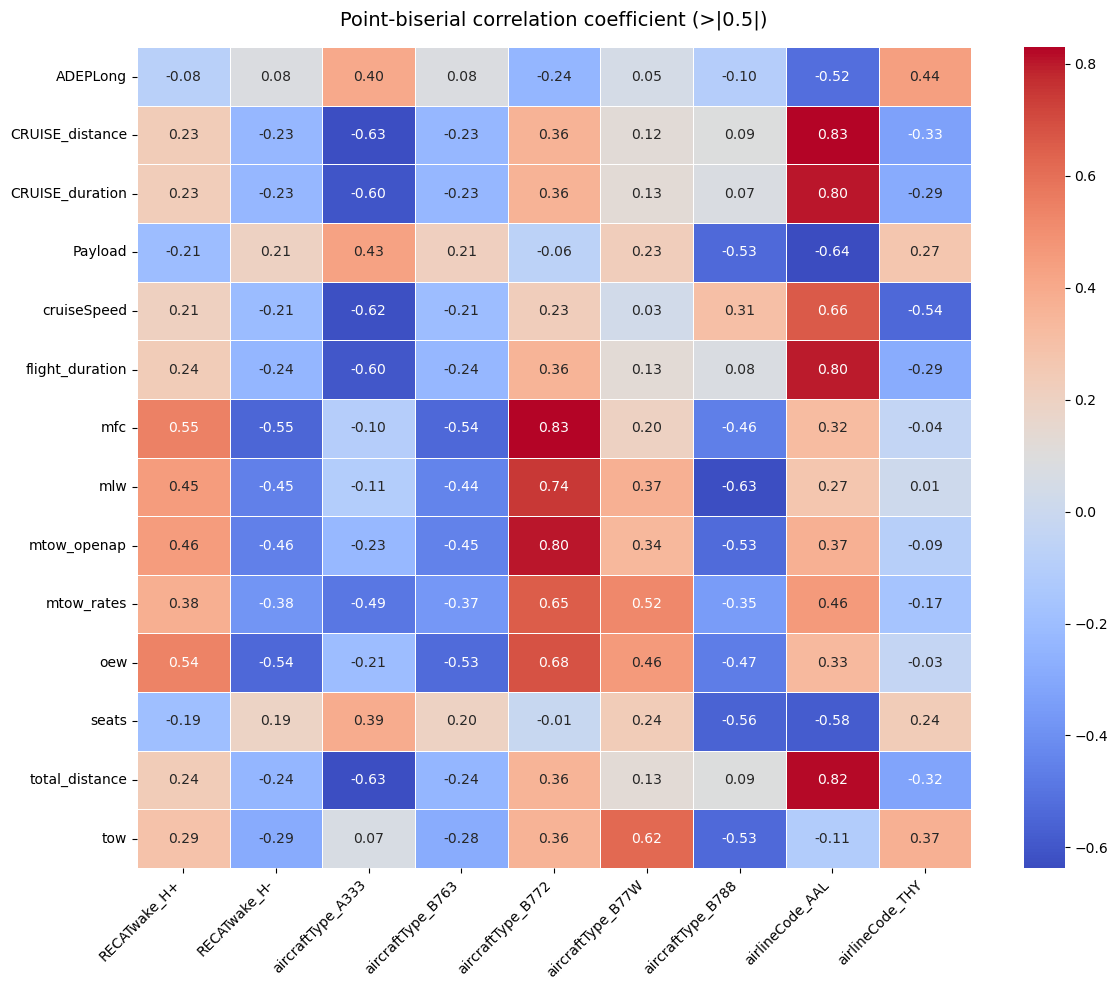

In [38]:
# --- 1) Threshold and filtering ---
threshold = 0.5

# Boolean masks for "any strong corr." per row and per column
rows_to_keep = (abs(pointbiserial_matrix) >= threshold).any(axis=1)
cols_to_keep = (abs(pointbiserial_matrix) >= threshold).any(axis=0)

# Subset the matrix
pointbiserial_matrix_filtered = pd.DataFrame(index=rows_to_keep[rows_to_keep == True].index, columns=cols_to_keep[cols_to_keep == True].index)

for cat in cols_to_keep[cols_to_keep == True].index:
    for num in rows_to_keep[rows_to_keep == True].index:
        try:
            pointbiserial_matrix_filtered.loc[num, cat] = stats.pointbiserialr(data_processed_df[cat], data_processed_df[num])[0]
        except Exception:
            pointbiserial_matrix_filtered.loc[num, cat] = np.nan
            
pointbiserial_matrix_filtered = pointbiserial_matrix_filtered.astype(float)            

plt.figure(figsize=(12, 10))
plt.title(f"Point-biserial correlation coefficient (>|{threshold}|)", pad=16, fontsize=14)
sns.heatmap(pointbiserial_matrix_filtered, fmt=".2f", cmap='coolwarm', annot=True, linewidths=0.5)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## M

In [47]:
numeric_cols = data_M.select_dtypes(include=['int64', 'float64']).columns.difference(CATEGORICAL_VARIABLES_M)

In [48]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', list(numeric_cols)),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='error'), CATEGORICAL_VARIABLES_M),
    ]
)

data_processed = preprocessor.fit_transform(data_M)

encoder = preprocessor.named_transformers_['cat']
data_processed_df = pd.DataFrame(
    data_processed, 
    columns=list(numeric_cols) + list(encoder.get_feature_names_out(CATEGORICAL_VARIABLES_M)),
    index=data_M.index
)

encoded_categorical = [col for col in data_processed_df.columns if col not in numeric_cols]
pointbiserial_matrix = pd.DataFrame(index=encoded_categorical, columns=numeric_cols)

for cat in encoded_categorical:
    for num in numeric_cols:
        try:
            pointbiserial_matrix.loc[cat, num] = stats.pointbiserialr(data_processed_df[cat], data_processed_df[num])[0]
        except Exception:
            pointbiserial_matrix.loc[cat, num] = np.nan

# Convert to float
pointbiserial_matrix = pointbiserial_matrix.T.astype(float)

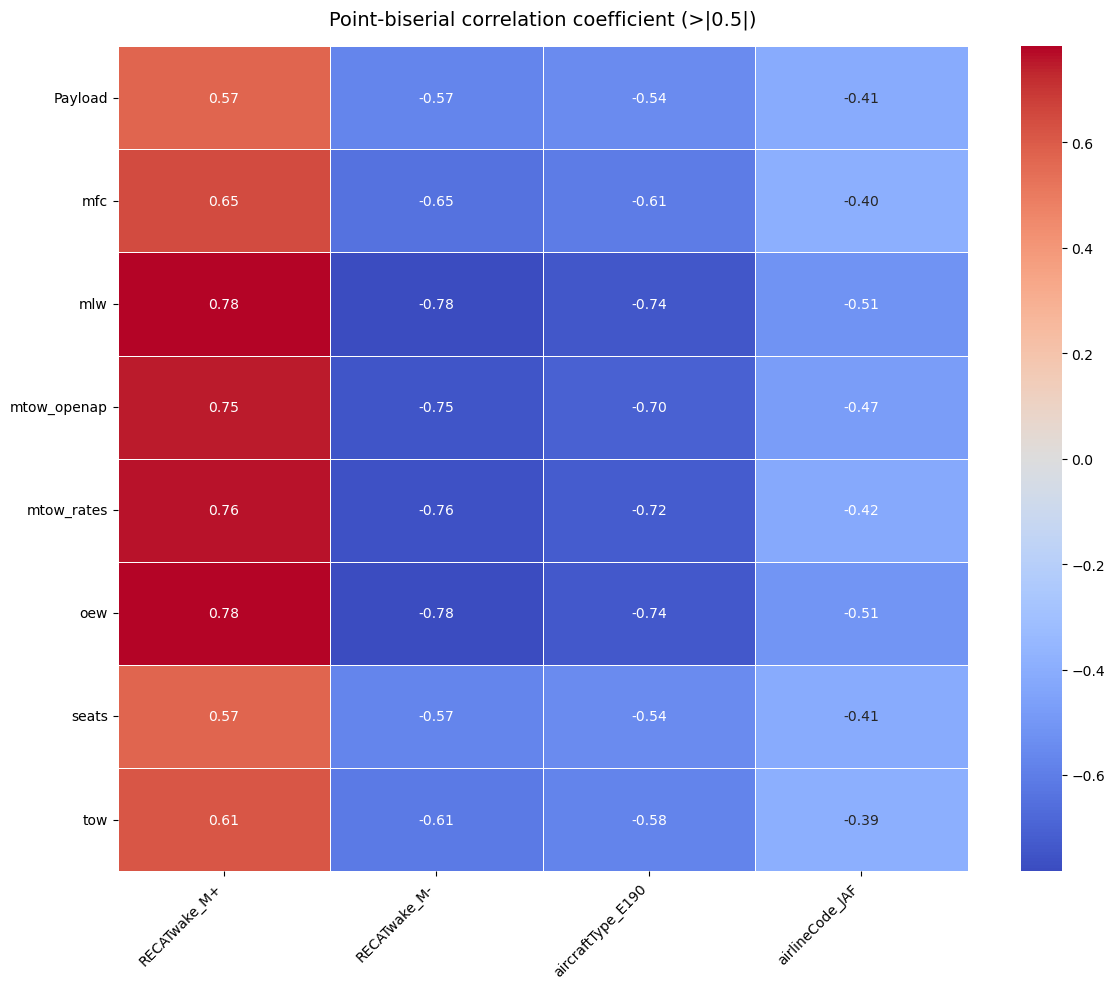

In [49]:
# --- 1) Threshold and filtering ---
threshold = 0.5

# Boolean masks for "any strong corr." per row and per column
rows_to_keep = (abs(pointbiserial_matrix) >= threshold).any(axis=1)
cols_to_keep = (abs(pointbiserial_matrix) >= threshold).any(axis=0)

# Subset the matrix
pointbiserial_matrix_filtered = pd.DataFrame(index=rows_to_keep[rows_to_keep == True].index, columns=cols_to_keep[cols_to_keep == True].index)

for cat in cols_to_keep[cols_to_keep == True].index:
    for num in rows_to_keep[rows_to_keep == True].index:
        try:
            pointbiserial_matrix_filtered.loc[num, cat] = stats.pointbiserialr(data_processed_df[cat], data_processed_df[num])[0]
        except Exception:
            pointbiserial_matrix_filtered.loc[num, cat] = np.nan
            
pointbiserial_matrix_filtered = pointbiserial_matrix_filtered.astype(float)            

plt.figure(figsize=(12, 10))
plt.title(f"Point-biserial correlation coefficient (>|{threshold}|)", pad=16, fontsize=14)
sns.heatmap(pointbiserial_matrix_filtered, fmt=".2f", cmap='coolwarm', annot=True, linewidths=0.5)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---

In [57]:
full_data.airlineCode.unique()

array(['BEL', 'AAL', 'JAF', 'THY', 'SAS', 'TOM', 'SWR', 'EIN', 'AUA',
       'EWG', 'TUI', 'TFL', 'TRA', 'BLX', 'EDW', 'AEA', 'SZS'],
      dtype=object)

In [ ]:
full_data[['adep', 'ades']].drop_duplicates()

,adep,ades
0,LEMD,EBBR
1,KJFK,LEMD
2,EBAW,LEMI
3,LTFM,LEMD
4,EKCH,LEMG
...,...,...
44065,GCTS,EGPF
44325,DIAP,EBBR
44405,GMTT,EBBR
44425,GCFV,EBBR


In [69]:
top_100_routes = full_data.groupby(['adep', 'ades'])['flightKey'] \
                          .count() \
                          .sort_values(ascending=False) \
                          .head(100)

In [70]:
pd.set_option('display.max_rows', None)
print(top_100_routes)

adep  ades
LSZH  LEBL    780
LEBL  LSZH    667
LSZH  LEPA    629
LEPA  LSZH    590
LTFM  LEBL    573
EBBR  LEMG    562
LTFM  LEMD    554
LEMD  EBBR    524
EBBR  LEMD    509
      LEAL    488
LEAL  EBBR    483
EIDW  LPFR    418
LEMG  EBBR    414
EBBR  LEBL    413
EIDW  LEBL    408
LTFM  LPPT    406
LEBL  EIDW    402
      EBBR    401
LPPR  LSZH    397
LPFR  EIDW    384
LSZH  LPPR    384
EIDW  LEMG    377
LPPT  LTFM    375
EBBR  LPPT    371
LOWW  LEBL    369
LEBL  LOWW    366
LSZH  LEMG    362
LPPT  EBBR    361
ESSA  LEMG    347
LOWW  LEPA    324
LEPA  LOWW    310
LTFM  LEMG    297
LSZH  LPPT    297
LPPT  LSZH    292
LPPR  EBBR    288
EBBR  LPPR    275
ESSA  LEAL    274
EKCH  LEPA    268
LEPA  EDDL    267
EIDW  LPPT    265
LEMD  EIDW    265
LPFR  EBBR    265
EDDL  LEPA    264
LEPA  ESSA    261
LEMG  LSZH    257
LEAL  ESSA    254
ENGM  LEAL    254
ESSA  LEPA    253
LEMG  ESSA    252
EIDW  LEMD    251
LPPT  EIDW    249
LEMG  EIDW    241
LEPA  EKCH    240
EBBR  LPFR    239
LTFM  LPPR    235

In [71]:
full_data.groupby('airlineCode')['flightKey'] \
                          .count() \
                          .sort_values(ascending=False)

airlineCode
TOM    6816
SWR    6360
BEL    5185
SAS    5052
JAF    4322
EIN    4264
TUI    3468
AAL    3349
THY    2743
AUA    1852
EWG     766
TFL     541
BLX     133
SZS      27
EDW       9
TRA       6
AEA       2
Name: flightKey, dtype: int64

In [72]:
full_data.aircraftType.unique()

array(['A320', 'B772', 'E190', 'A333', 'A20N', 'B738', 'A21N', 'A321',
       'A319', 'BCS3', 'B38M', 'A343', 'BCS1', 'B788', 'B789', 'A332',
       'B737', 'E195', 'B763', 'CRJ9', 'B77W', 'A359', 'B39M', 'B739',
       'B752'], dtype=object)